/mnt/miniconda3/envs/migration/lib/python3.12/site-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo


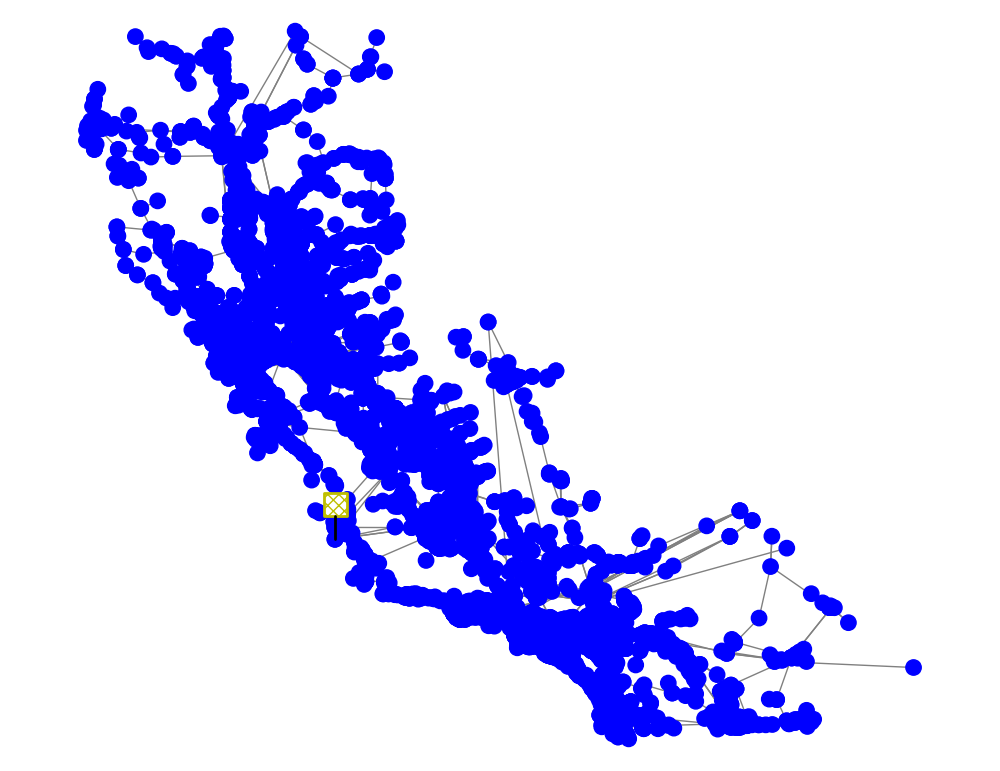

<Axes: >

In [1]:
import pandas as pd
import pandapower.converter.matpower as ppcv
import pandapower.toolbox as pbt

from pandapower.plotting import simple_plot
from pandapower.plotting.geo import convert_geodata_to_geojson
from pandas import DataFrame

buses_csv = "CATS_buses.csv"
grid_matlab = "CaliforniaTestSystem.m"

cats_grid = ppcv.from_mpc(mpc_file=grid_matlab, f_hz=60)

# Load bus and generator information from CSV files
bus_df: DataFrame = pd.read_csv(buses_csv) 

# Reindex the buses in the grid
reindex_table = dict(zip(cats_grid.bus.index, bus_df["bus_i"]))
pbt.reindex_buses(cats_grid, bus_lookup=reindex_table)

# Index the buses by bus_id field
bus_df.set_index('bus_i', inplace=True)

if not hasattr(cats_grid, 'bus_geodata') or cats_grid.bus_geodata.empty:
    cats_grid.bus_geodata = pd.DataFrame(columns=['x', 'y'])

for bus_idx in cats_grid.bus.index:
    if bus_idx in bus_df.index:
        # Update all buses to include geodata
        lon = bus_df.loc[bus_idx, "Lon"]
        lat = bus_df.loc[bus_idx, "Lat"]
        cats_grid.bus_geodata.loc[bus_idx, ['x', 'y']] = [lon, lat]

        # Update all buses to include metainformation
        cats_grid.bus.loc[bus_idx, 'type'] = bus_df.loc[bus_idx, 'Type']

missing_geo: int = len(cats_grid.bus) - len(cats_grid.bus_geodata)
if missing_geo > 0:
    print(f"Warning: {missing_geo} buses do not have geodata.")

convert_geodata_to_geojson(cats_grid)
simple_plot(net = cats_grid)